In [2]:
import pandas as pd
from fredapi import Fred
import yfinance as yf

In [3]:
FIRST_DATE = "1954-01-03"
FINAL_DATE = "2024-12-31"
AUTO_ADJUST = True
fred_api_key = "98af04c2eaf13d24aea2856385e845cc"

In [5]:

fred = Fred(api_key=fred_api_key)

ffr: pd.Series = fred.get_series("DFF")
ffr_y = ffr / 100
ffr_d = (ffr_y + 1.0) ** (1/252) - 1.0
ffr_y.shape, ffr_d.shape

# store risk free return (Fed Fund Rate - FFR)
pd.DataFrame(ffr_d, columns=["ffr_d"]).to_parquet("./return/ffr_d.parquet")
pd.DataFrame(ffr_y, columns=["ffr_y"]).to_parquet("./return/ffr_y.parquet")

In [15]:
universe = [
    "QQQ", "SPY", "IWM", # market
    "EFA", "EEM",  # international equities
    "AGG", "TLT", "IEF", "LQD", "HYG",  # bonds
    "GLD", "SLV", "PPLT",  # precious metals
    "DBC",  # broad commodities
    "DBA", "CORN", "WEAT", "SOYB",  # agriculture
    "VNQ",  # US REITs
]

etf_data: pd.DataFrame = yf.download(universe, start=FIRST_DATE, auto_adjust=AUTO_ADJUST)
closes: pd.DataFrame = etf_data["Close"]
ret_d = closes.pct_change().dropna(how="all")
ret_d.to_parquet("./return/ret_d.parquet")

[*********************100%***********************]  19 of 19 completed


<Axes: xlabel='Date'>

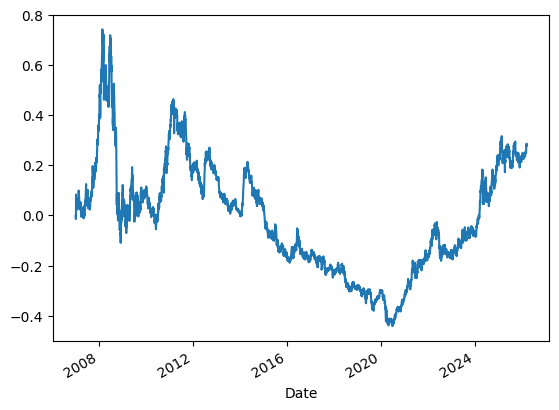

In [14]:
((ret_d["DBA"]+1.0).cumprod()-1.0).plot()

<Axes: xlabel='Date'>

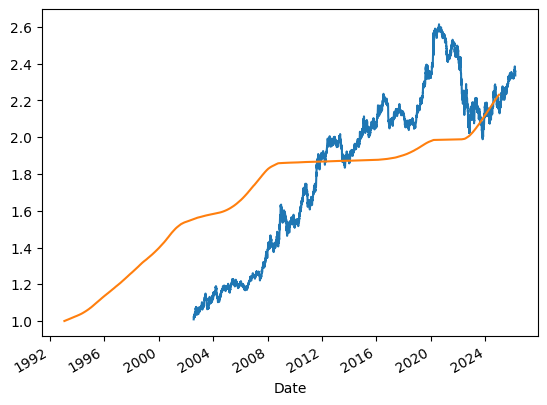

In [140]:
(ret_d["IEF"]+1.0).cumprod().plot()
(ffr_d.reindex(rd.index)+1.0).cumprod().plot()